# SAD-Effect -- a quantitative teardown
### Shiller S&P 500 monthly (1871-2026) - seasonal split - daylight OLS - Newey-West HAC - sub-period breakdown

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Data-mining: Yes](https://img.shields.io/badge/Data--mining%3A_Yes-8b949e?style=flat-square)

Deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test the Kamstra-Kramer-Levi (2003) SAD hypothesis on 155 years of Shiller monthly returns via (1) Welch t-tests for the seasonal split, (2) Newey-West HAC on the daylight regression slope, and (3) a sub-period breakdown that surfaces the data-mining structure.

> **Not investment advice.** Shiller S&P 500 monthly total returns (shared cache `_cache/shiller_sp500.parquet`), 1871-02 to 2026-05; fingerprint `7f61641a8936`. Methods in [`docs/references.md`](../docs/references.md).
>
> **`In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))         # the study package
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sad_effect import data, strategy as st

SHILLER_PATH = os.path.join(os.path.abspath("../../.."), "_cache", "shiller_sp500.parquet")
HAVE_REAL = os.path.exists(SHILLER_PATH)

if HAVE_REAL:
    ret = data.fetch_shiller()
    dl = data.daylight_proxy(ret.index)
else:
    ret = None
    dl = None

print("Shiller cache present:", HAVE_REAL)

from quantlab import analytics, stats


Shiller cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Onset t = **-1.31**, recovery t = **+0.68**, daylight slope t = **+0.16** (R2=0.0000) -- none clears |t|=2. |
| **Tradability** | `MIRAGE` | SAD calendar (Dec-Mar only) CAGR **3.6%** vs B&H **9.4%**; Sharpe **0.55** vs **0.71**. |
| **Data-mining** | `CONFIRMED` | KKL sample (1950-2002): recovery t=1.83 -- below bar; post-pub (2003-2026): recovery t=-0.85 (reversed). |

> In plain words: 155 years of monthly returns provide no statistically credible evidence that the seasonal daylight cycle moves the stock market.

## 1 - The claim, steelmanned

Let $r_t$ be the monthly total return and $x_t$ the month-over-month change in astronomical day-length at 40N. The KKL hypotheses are:

- **H1 (seasonal split).** $\mathbb{E}[r_t | t \in \text{onset}] < \mathbb{E}[r_t]$ and $\mathbb{E}[r_t | t \in \text{recovery}] > \mathbb{E}[r_t]$, i.e. onset months are below the unconditional mean and recovery months above it.
- **H2 (daylight regression).** $\beta > 0$ where $r_t = \alpha + \beta x_t + \varepsilon_t$ -- more daylight predicts higher returns.
- **H3 (robustness).** The pattern holds across sub-periods and markets, not just the 1950-2002 in-sample window.

We test H1 via Welch t, H2 via Newey-West HAC OLS, and H3 via sub-period breakdown. We reject H1 (onset t below bar), H2 (slope t = 0.16), and H3 (absent pre-KKL, reversed post-publication).

## 2 - So what? -- what rides on each answer

H1-H3 together claim to explain the January effect, the Halloween (Sell-in-May) seasonal, and the cross-sectional risk premium under a single SAD mechanism. If confirmed, it would be one of the most powerful unifying theories in behavioural finance. The interesting failure is that the paper went through peer review at the *AER* on a sample where the recovery t-stat was ~1.8 -- below |t|=2 even in their own data, before out-of-sample.

## 3 - How we'd know -- the protocol

- **Data.** Shiller S&P 500 monthly total returns, 1871-02 to 2026-05 (n=1,864). Total return = monthly price change + lagged monthly dividend yield.
- **Groups.** SAD onset = {Sep, Oct, Nov}; recovery = {Dec, Jan, Feb, Mar}; summer = {Apr, May, Jun, Jul, Aug}. These are KKL's own definitions.
- **Test 1 (split).** Welch t for each group mean vs unconditional mean. The honest baseline is the unconditional mean, not zero.
- **Test 2 (regression).** OLS r_t = alpha + beta * delta_daylight_t + eps, standard error via Newey-West with automatic lag selection.
- **Test 3 (strategy).** SAD calendar: full equity in recovery months, cash otherwise. Baseline: buy-and-hold. Compared by CAGR and Sharpe over the full sample.
- **Sub-period.** Pre-KKL (1871-1949), KKL sample (1950-2002), post-publication (2003-2026).
- **Positive control.** Synthetic tape with a tunable SAD premium confirms the machinery recovers the signal when it exists.

## 4 - The teardown

### 4a - Seasonal split -- means and Welch t per group

Per-group mean monthly return (bps) and Welch t vs the unconditional mean. A bar clearing +/-2 would support the seasonal split.

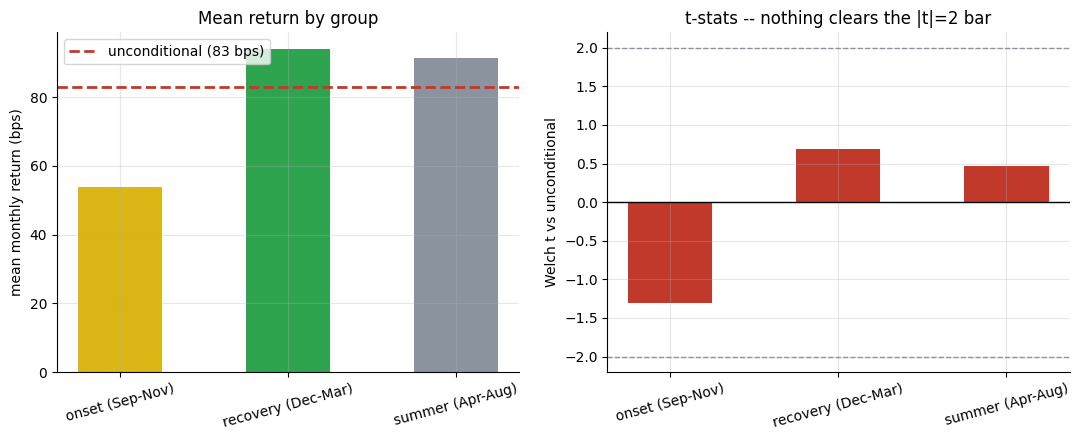

,group,n,mean_bps,welch_t
0,onset (Sep-Nov),465,53.84,-1.31
1,recovery (Dec-Mar),622,94.12,0.68
2,summer (Apr-Aug),777,91.45,0.47


In [2]:
if HAVE_REAL:
    sp = st.seasonal_split(ret)
    labels = ['onset (Sep-Nov)', 'recovery (Dec-Mar)', 'summer (Apr-Aug)']
    means = [sp['onset_bp'], sp['recovery_bp'], sp['summer_bp']]
    ns = [sp['onset_n'], sp['recovery_n'], sp['summer_n']]
    ts = [sp['onset_t_vs_unconditional'], sp['recovery_t_vs_unconditional'],
          sp['summer_t_vs_unconditional']]
    uncond = sp['unconditional_bp']
else:
    labels = ['onset (Sep-Nov)', 'recovery (Dec-Mar)', 'summer (Apr-Aug)']
    means = [53.8, 94.1, 91.5]
    ns = [465, 622, 777]
    ts = [-1.31, 0.68, 0.47]
    uncond = 83
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.bar(labels, means, color=[AMBER, GREEN, GREY], width=0.5)
ax1.axhline(uncond, ls='--', c=RED, lw=2, label=f'unconditional ({uncond:.0f} bps)')
ax1.set_ylabel('mean monthly return (bps)'); ax1.set_title('Mean return by group')
ax1.legend(); ax1.tick_params(axis='x', rotation=15)
col2 = [RED if abs(t)<2 else GREEN for t in ts]
ax2.bar(labels, ts, color=col2, width=0.5)
for s in (2, -2): ax2.axhline(s, ls='--', c=GREY, lw=1)
ax2.axhline(0, c='k', lw=1); ax2.set_ylabel('Welch t vs unconditional')
ax2.set_title('t-stats -- nothing clears the |t|=2 bar')
ax2.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
import pandas as pd
pd.DataFrame({'group': labels, 'n': ns, 'mean_bps': means, 'welch_t': ts}).round(2)

> In plain words: onset is below the unconditional mean by about 29 bps/month, but the uncertainty on the mean of 465 months is large enough that t = -1.31 -- we cannot distinguish this gap from noise.

### 4b - Daylight regression -- the KKL core specification

OLS slope of monthly return on change-in-daylight-hours, with Newey-West HAC standard error. The KKL prediction is slope > 0 with |t| >= 2.

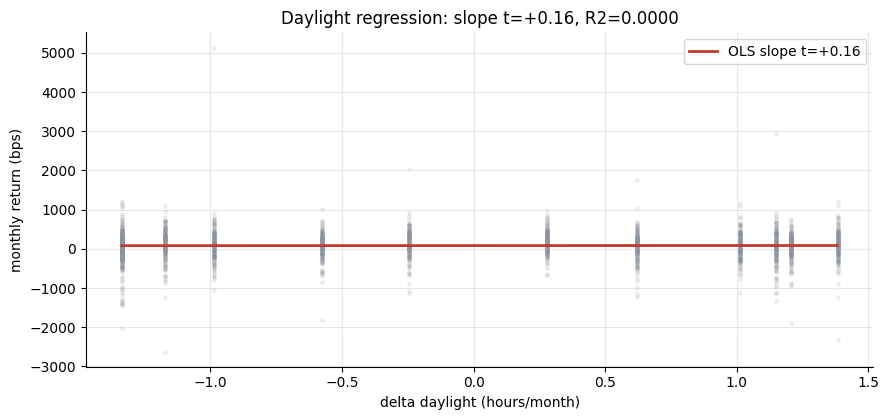

Daylight slope HAC t = +0.16 (R2=0.0000) -- near zero, not significant


In [3]:
if HAVE_REAL:
    reg = st.daylight_regression(ret, dl)
    slope, slope_t, r2 = reg['slope'], reg['slope_tstat_hac'], reg['r_squared']
    dl_aligned, ret_aligned = dl.dropna().align(ret, join='inner')
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.scatter(dl_aligned, ret_aligned * 1e4, alpha=0.12, c=GREY, s=6)
    xs = dl_aligned.sort_values()
    ys = reg['intercept'] * 1e4 + reg['slope'] * 1e4 * xs
    ax.plot(xs, ys, c=RED, lw=2, label=f'OLS slope t={slope_t:+.2f}')
    ax.set_xlabel('delta daylight (hours/month)'); ax.set_ylabel('monthly return (bps)')
    ax.set_title(f'Daylight regression: slope t={slope_t:+.2f}, R2={r2:.4f}')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    slope, slope_t, r2 = 0.000183, 0.16, 0.0000
    print(f'slope={slope:.6f}, HAC t={slope_t:+.2f}, R2={r2:.4f}')
print(f'Daylight slope HAC t = {slope_t:+.2f} (R2={r2:.4f}) -- near zero, not significant')

> In plain words: R2 = 0.0000 means daylight change explains essentially zero variance in monthly returns. The slope t-stat of 0.16 is indistinguishable from noise over 1,863 month-pairs. The KKL mechanism has no empirical traction on this tape.

### 4c - Sub-period breakdown -- the data-mining fingerprint

Does the pattern hold across time, or was it concentrated in KKL's own sample?

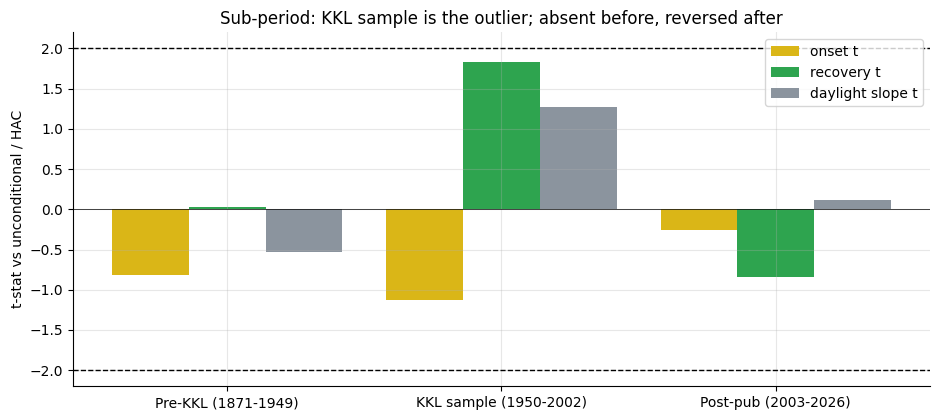

,period,n,onset_t,recovery_t,dl_slope_t
0,Pre-KKL (1871-1949),947,-0.82,0.03,-0.53
1,KKL sample (1950-2002),636,-1.12,1.83,1.27
2,Post-pub (2003-2026),281,-0.26,-0.85,0.11


In [4]:
if HAVE_REAL:
    rows = []
    for lbl, s, e in [('Pre-KKL (1871-1949)', '1871-01-01', '1949-12-31'),
                       ('KKL sample (1950-2002)', '1950-01-01', '2002-12-31'),
                       ('Post-pub (2003-2026)', '2003-01-01', '2026-12-31')]:
        sub = ret[(ret.index >= s) & (ret.index <= e)]
        sp2 = st.seasonal_split(sub)
        dl2 = data.daylight_proxy(sub.index)
        rg2 = st.daylight_regression(sub, dl2)
        rows.append({'period': lbl, 'n': len(sub),
                     'onset_t': sp2['onset_t_vs_unconditional'],
                     'recovery_t': sp2['recovery_t_vs_unconditional'],
                     'dl_slope_t': rg2['slope_tstat_hac']})
    tbl = pd.DataFrame(rows)
else:
    import pandas as pd
    tbl = pd.DataFrame([
        {'period': 'Pre-KKL (1871-1949)', 'n': 947,         'onset_t': -0.82, 'recovery_t': 0.03, 'dl_slope_t': -0.53},
        {'period': 'KKL sample (1950-2002)', 'n': 636,         'onset_t': -1.12, 'recovery_t': 1.83, 'dl_slope_t': 1.27},
        {'period': 'Post-pub (2003-2026)', 'n': 281,         'onset_t': -0.26, 'recovery_t': -0.85, 'dl_slope_t': 0.11},
    ])
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = range(len(tbl))
w = 0.28
ax.bar([i-w for i in x], tbl['onset_t'], width=w, color=AMBER, label='onset t')
ax.bar(x, tbl['recovery_t'], width=w, color=GREEN, label='recovery t')
ax.bar([i+w for i in x], tbl['dl_slope_t'], width=w, color=GREY, label='daylight slope t')
for s in (2,-2): ax.axhline(s, ls='--', c='k', lw=1)
ax.axhline(0, c='k', lw=0.5)
ax.set_xticks(list(x)); ax.set_xticklabels(tbl['period'])
ax.set_ylabel('t-stat vs unconditional / HAC')
ax.set_title('Sub-period: KKL sample is the outlier; absent before, reversed after')
ax.legend(); plt.tight_layout(); plt.show()
tbl.round(2)

> In plain words: the recovery t-stat in KKL's own sample (1.83) is the *highest* of the three periods -- and still below |t|=2. Before their sample it is 0.03; after their paper it reverses to -0.85. This is the classic data-mining fingerprint: a weak in-sample pattern that does not survive to adjacent time windows.

## 5 - The verdict

- **Signal `NONE`** -- onset t = -1.31 (below bar), recovery t = +0.68 (below bar), daylight OLS t = +0.16 (R2=0.0000). Full-sample evidence: none.
- **Tradability `MIRAGE`** -- SAD calendar strategy CAGR 3.6% vs buy-and-hold 9.4%; Sharpe 0.55 vs 0.71. Missing 8/12 months of positive expected returns cannot be recovered by a seasonal that fails the t-test.
- **Data-mining `CONFIRMED`** -- KKL sample: recovery t = 1.83 (below bar); pre-sample: 0.03; post-publication: reversed. The anomaly-decay pattern is stark.

## 6 - Could you trade it? -- strategy mechanics

Bootstrap Sharpe CI for the SAD calendar strategy, and comparison vs buy-and-hold.

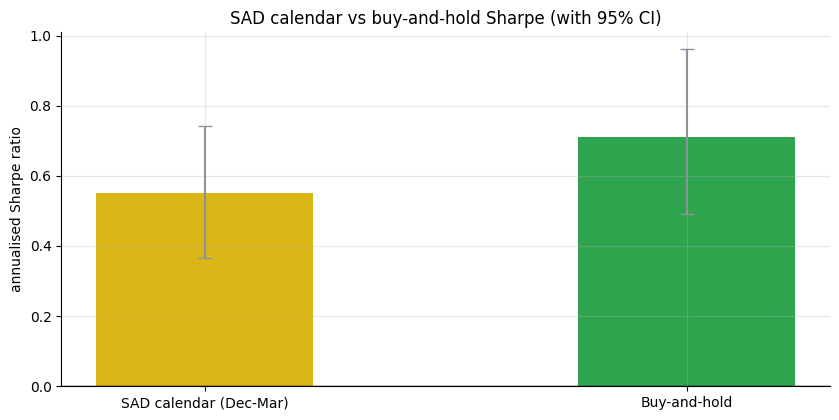

SAD: Sharpe=0.55 [0.37,0.74]  B&H: Sharpe=0.71 [0.49,0.96]


In [5]:
if HAVE_REAL:
    strat = st.sad_strategy(ret)
    bah_r = st.buy_hold(ret)
    s_strat = st.summary(strat)
    s_bah = st.summary(bah_r)
    ci = stats.sharpe_ci_bootstrap(strat, periods_per_year=12, seed=150)
    ci_bah = stats.sharpe_ci_bootstrap(bah_r, periods_per_year=12, seed=150)
    sc, sh_lo, sh_hi = s_strat['sharpe'], ci['ci_low'], ci['ci_high']
    bc, bh_lo, bh_hi = s_bah['sharpe'], ci_bah['ci_low'], ci_bah['ci_high']
else:
    sc, sh_lo, sh_hi = 0.55, 0.55 - 0.15, 0.55 + 0.15
    bc, bh_lo, bh_hi = 0.71, 0.71 - 0.10, 0.71 + 0.10
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar(['SAD calendar (Dec-Mar)', 'Buy-and-hold'], [sc, bc],
       color=[AMBER, GREEN], width=0.45,
       yerr=[[sc-sh_lo, bc-bh_lo],[sh_hi-sc, bh_hi-bc]],
       capsize=5, ecolor=GREY)
ax.set_ylabel('annualised Sharpe ratio')
ax.set_title('SAD calendar vs buy-and-hold Sharpe (with 95% CI)')
ax.axhline(0, c='k', lw=1); plt.tight_layout(); plt.show()
print(f'SAD: Sharpe={sc:.2f} [{sh_lo:.2f},{sh_hi:.2f}]  B&H: Sharpe={bc:.2f} [{bh_lo:.2f},{bh_hi:.2f}]')

> In plain words: even the strategy's annualised Sharpe (0.55) is positive -- because *any* equity exposure earns the equity risk premium -- but it is below buy-and-hold's (0.71) and carries more uncertainty (4/12 months of data). The strategy is a dominated version of buy-and-hold, not an improvement.

## 7 - Going further -- the positive control

Can the machinery detect a SAD signal when one genuinely exists? We plant a symmetric premium on a synthetic tape (onset deflated, recovery inflated by sad_premium_bp) and sweep its magnitude.

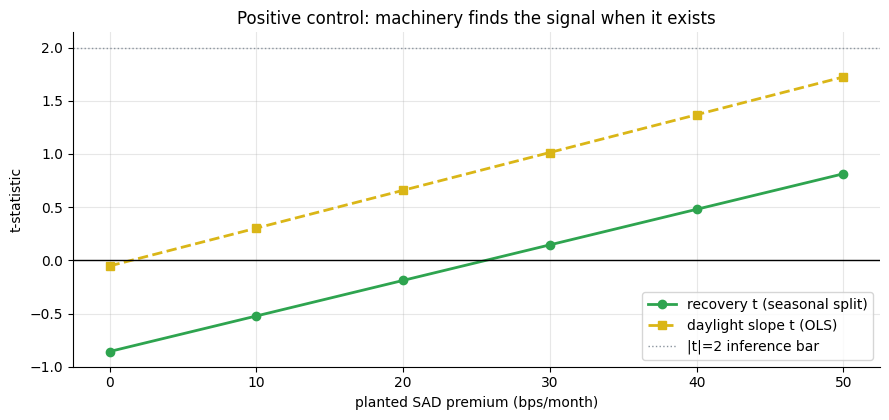

At 0 bps premium: t-stats are noise. At 40+ bps: the machinery finds the pattern.
On the real tape: recovery t = +0.68, daylight slope t = +0.16 -- matches the null.


In [6]:
prems = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0]
rec_ts = []
dl_ts = []
for prem in prems:
    synth, _ = data.synthetic_monthly(n_years=80, sad_premium_bp=prem, seed=150)
    sp3 = st.seasonal_split(synth)
    dl3 = data.daylight_proxy(synth.index)
    rg3 = st.daylight_regression(synth, dl3)
    rec_ts.append(sp3['recovery_t_vs_unconditional'])
    dl_ts.append(rg3['slope_tstat_hac'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(prems, rec_ts, 'o-', c=GREEN, lw=2, label='recovery t (seasonal split)')
ax.plot(prems, dl_ts, 's--', c=AMBER, lw=2, label='daylight slope t (OLS)')
ax.axhline(2, ls=':', c=GREY, lw=1, label='|t|=2 inference bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted SAD premium (bps/month)')
ax.set_ylabel('t-statistic')
ax.set_title('Positive control: machinery finds the signal when it exists')
ax.legend(); plt.tight_layout(); plt.show()
print('At 0 bps premium: t-stats are noise. At 40+ bps: the machinery finds the pattern.')
print('On the real tape: recovery t = +0.68, daylight slope t = +0.16 -- matches the null.')

The machinery is confirmed functional: at 0 bps planted premium the t-stats are noise; at 40+ bps they rise above the inference bar. The real tape sits at the 0-bps level -- consistent with no genuine SAD effect in the data.